In [1]:
import pandas as pd

df = pd.read_csv("hotel_booking.csv")

print(df.head())

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  customer_type  \
0                        0                     0       2  ...      Transient   
1   

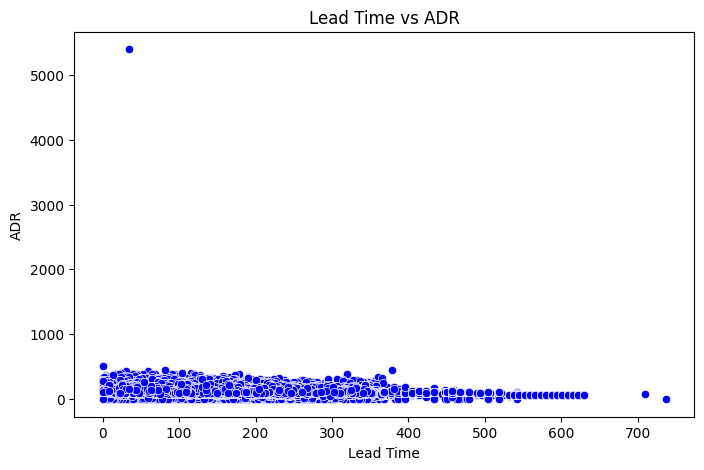

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="lead_time",
    y="adr",
    color="blue"
)

plt.title("Lead Time vs ADR")
plt.xlabel("Lead Time")
plt.ylabel("ADR")

plt.show()

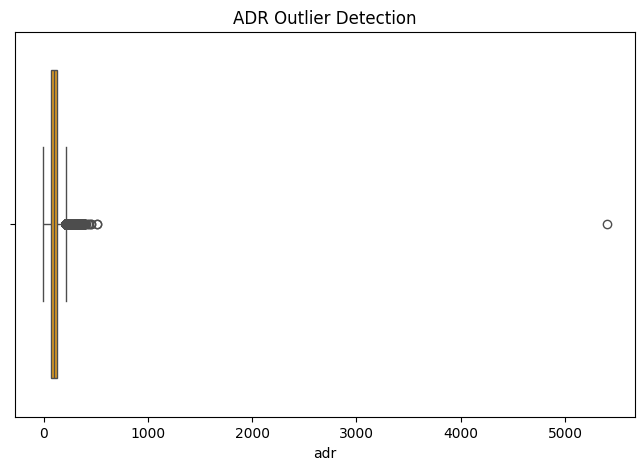

In [3]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["adr"],
    color="orange"
)

plt.title("ADR Outlier Detection")

plt.show()

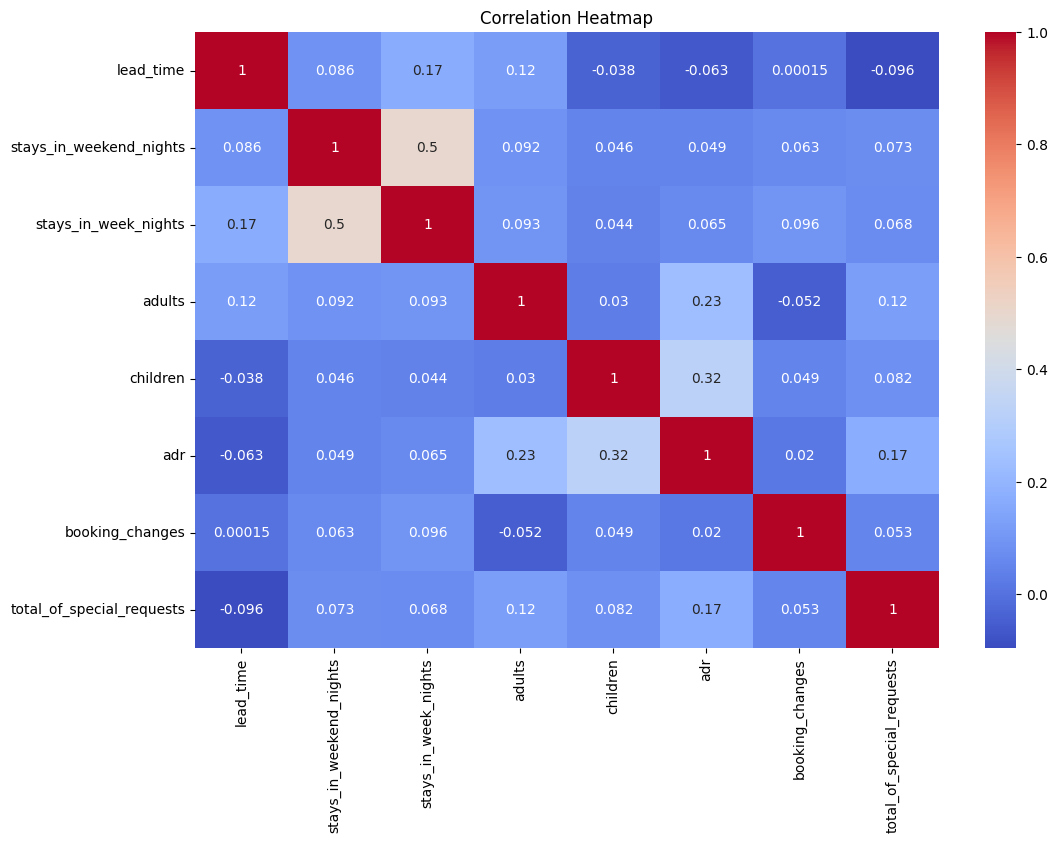

In [4]:
plt.figure(figsize=(12,8))

corr = df[
    [
        "lead_time",
        "stays_in_weekend_nights",
        "stays_in_week_nights",
        "adults",
        "children",
        "adr",
        "booking_changes",
        "total_of_special_requests"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

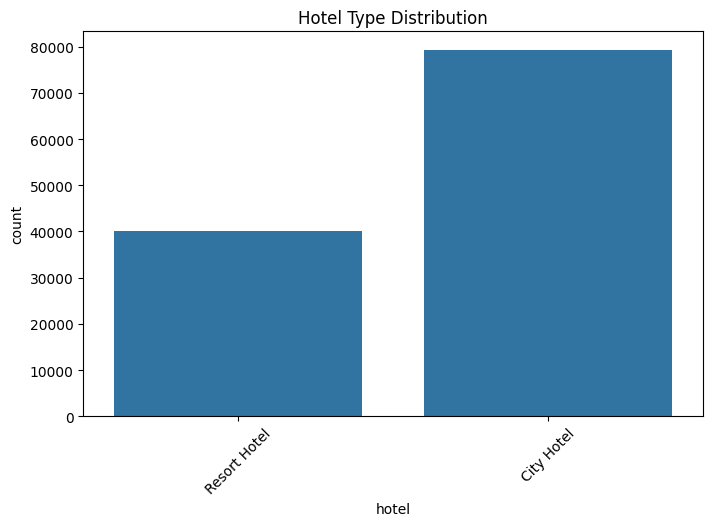

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="hotel"
)

plt.xticks(rotation=45)

plt.title("Hotel Type Distribution")

plt.show()

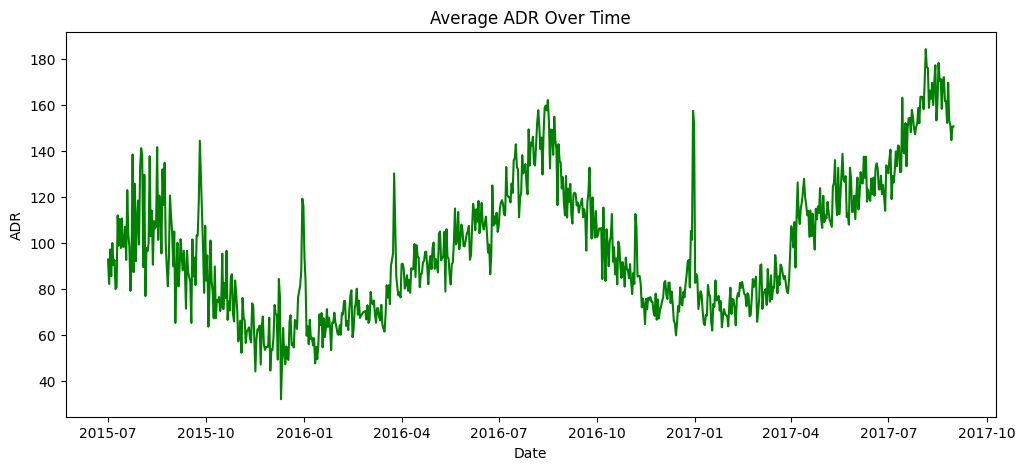

In [6]:
df["arrival_date"] = pd.to_datetime(
    df["arrival_date_year"].astype(str) + "-" +
    df["arrival_date_month"] + "-" +
    df["arrival_date_day_of_month"].astype(str),
    errors="coerce"
)

daily = df.groupby("arrival_date")["adr"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    daily,
    color="green"
)

plt.title("Average ADR Over Time")

plt.xlabel("Date")
plt.ylabel("ADR")

plt.show()

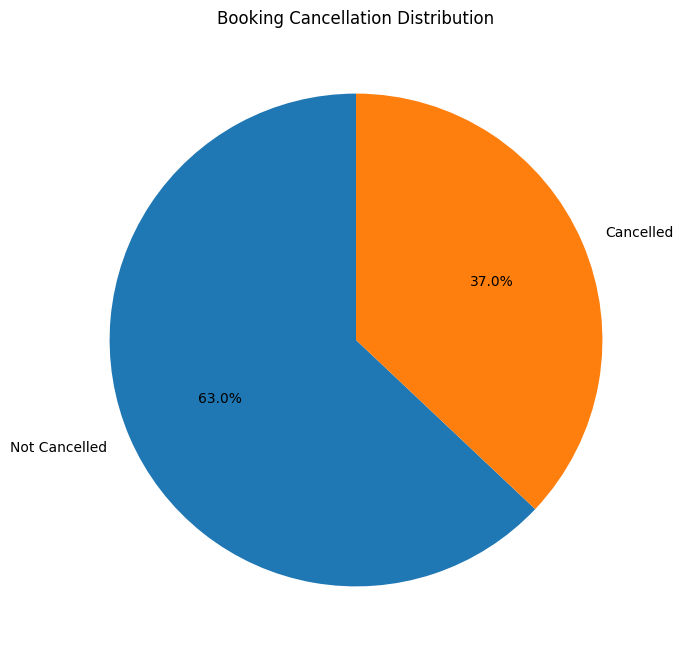

In [7]:
cancellation = df["is_canceled"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    cancellation,
    labels=["Not Cancelled", "Cancelled"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Booking Cancellation Distribution")

plt.show()

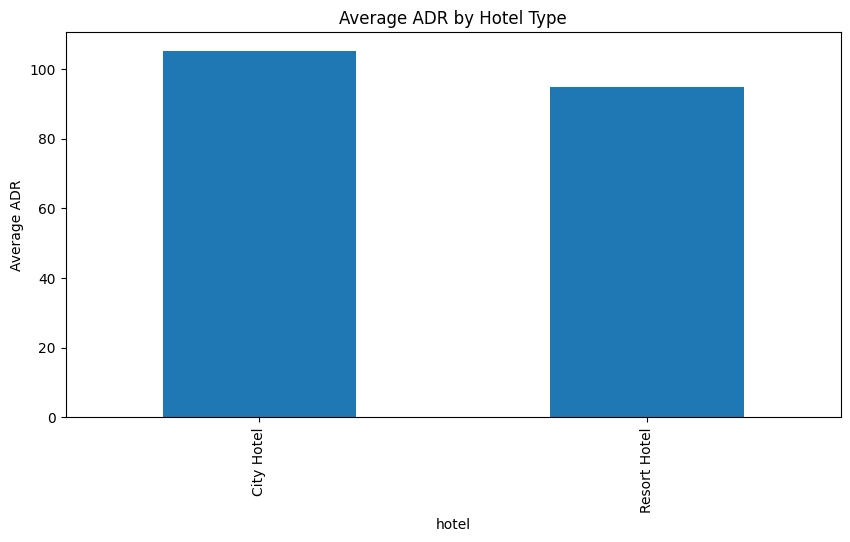

In [8]:
hotel = df.groupby("hotel")["adr"].mean()

hotel = hotel.sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))

hotel.plot(kind="bar")

plt.title("Average ADR by Hotel Type")

plt.ylabel("Average ADR")

plt.show()

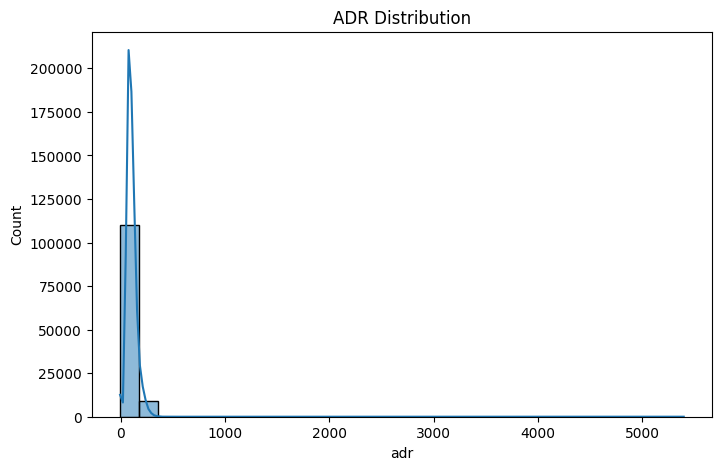

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["adr"],
    bins=30,
    kde=True
)

plt.title("ADR Distribution")

plt.show()

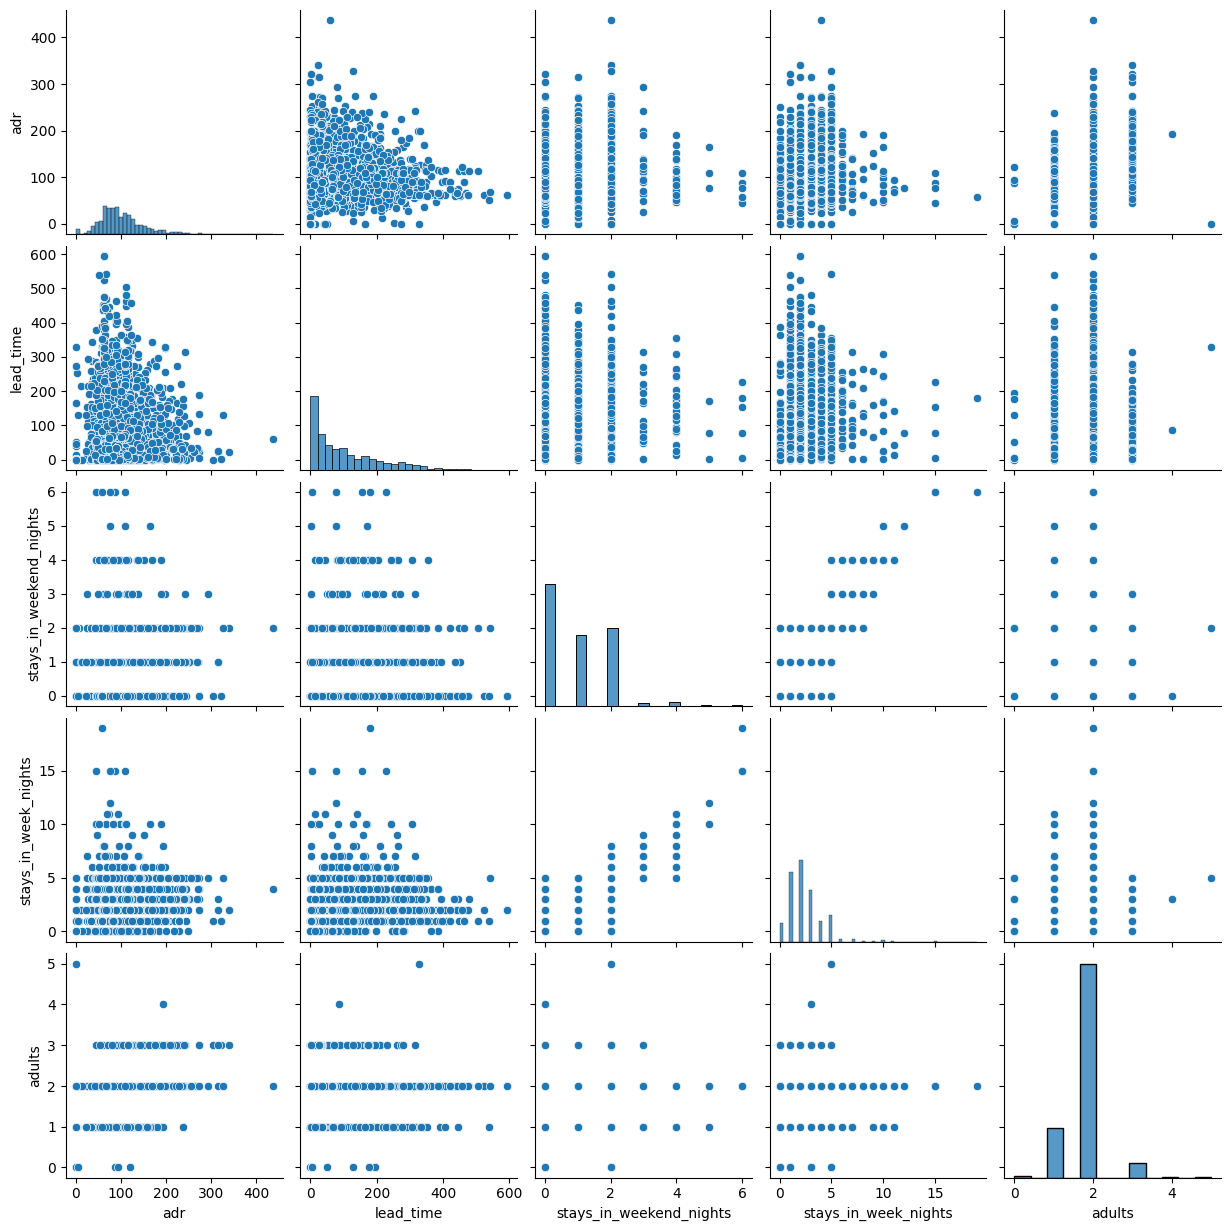

In [10]:
sns.pairplot(
    df[
        [
            "adr",
            "lead_time",
            "stays_in_weekend_nights",
            "stays_in_week_nights",
            "adults"
        ]
    ].dropna().sample(2000, random_state=42)
)

plt.show()

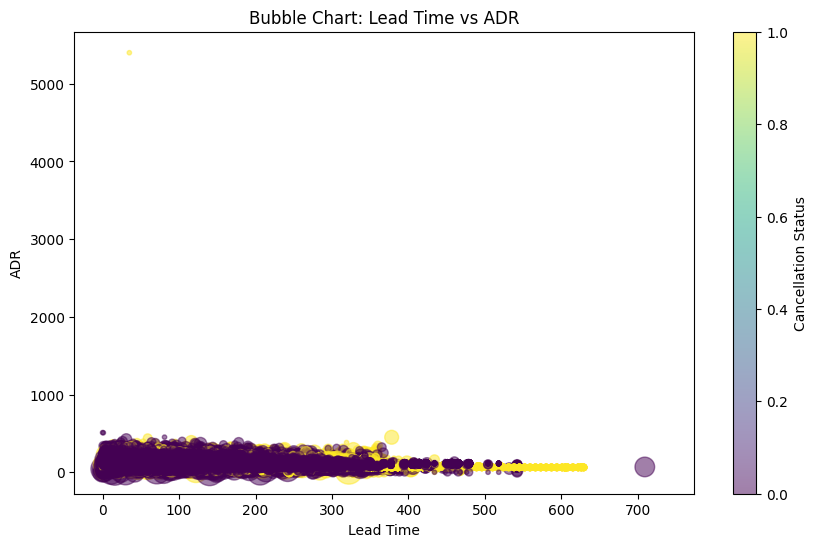

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["lead_time"],
    df["adr"],
    s=df["stays_in_week_nights"] * 10,
    alpha=0.5,
    c=df["is_canceled"],
    cmap="viridis"
)

plt.colorbar(label="Cancellation Status")

plt.xlabel("Lead Time")
plt.ylabel("ADR")

plt.title("Bubble Chart: Lead Time vs ADR")

plt.show()

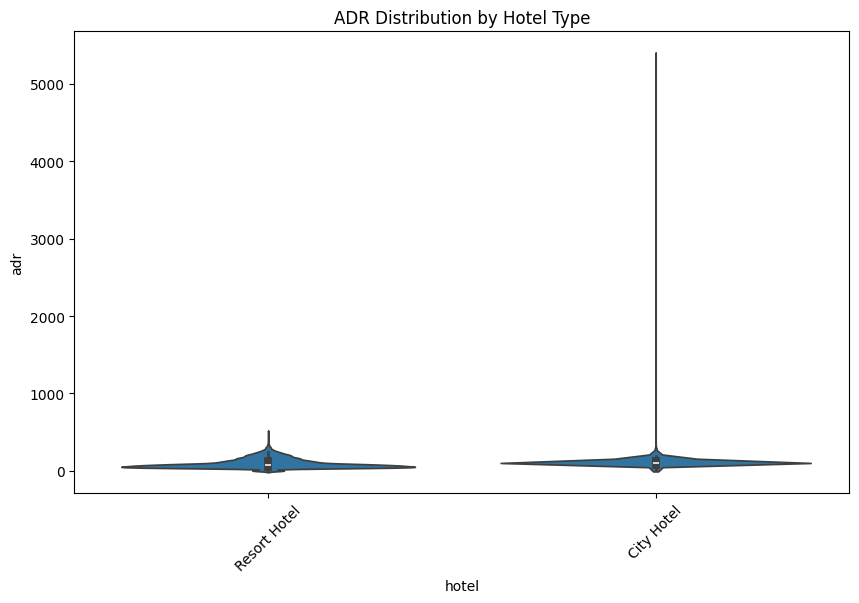

In [12]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x="hotel",
    y="adr"
)

plt.xticks(rotation=45)

plt.title("ADR Distribution by Hotel Type")

plt.show()

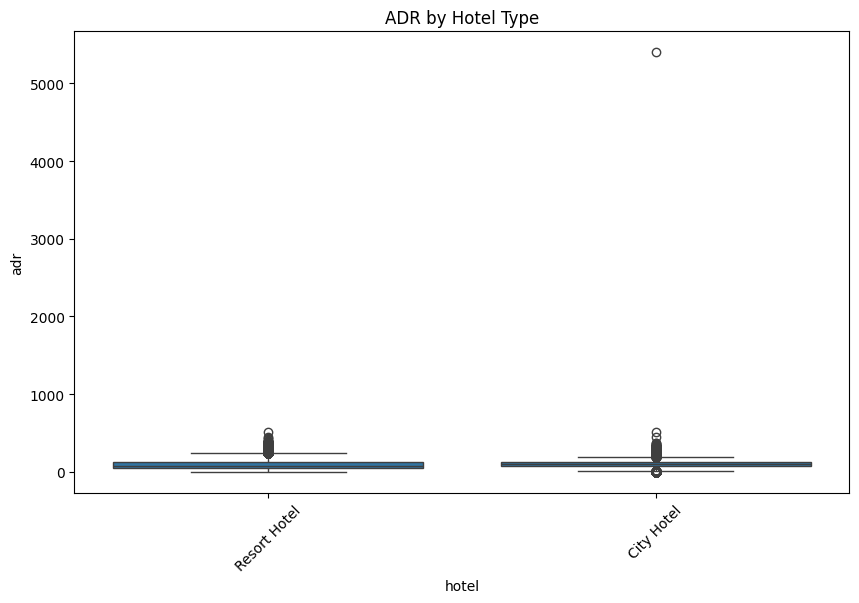

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="hotel",
    y="adr"
)

plt.xticks(rotation=45)

plt.title("ADR by Hotel Type")

plt.show()